In [1]:
import pandas as pd
import numpy as np

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel("LIGHTWEIGHT_CONCRETE.xlsx", header=[0,1,2])

In [4]:
df.head()

S. No                  Authors Input Variables           \
  Unnamed: 0_level_1       Unnamed: 1_level_1          Binder Pozzolan   
  Unnamed: 0_level_2       Unnamed: 1_level_2         (kg/m3)  (kg/m3)   
0                  1  Tikalsky., et al., 2004           420.0      0.0   
1                  2                      NaN           411.0      0.0   
2                  3                      NaN           149.0    302.0   
3                  4                      NaN           311.0      0.0   
4                  5                      NaN            57.0    268.0   

                                                                           \
  Fine aggregate   Water Foaming agent Measured Density Period of Testing   
         (kg/m3) (kg/m3)       (kg/m3)          (kg/m3)            (Days)   
0            0.0   168.0          39.4            629.0                28   
1            0.0   186.0          38.5            631.0                28   
2            0.0   190.0          35.8            678.0                28   
3            0.0   141.0          44.3            497.0                28   
4          885.0   163.0          20.0           1396.0                28   

      Output Variables  
  Compressive Strength  
                 (MPa)  
0                 1.77  
1                 2.07  
2                 1.09  
3                 0.71  
4                 0.25

In [5]:
df.columns = ["s.no", "authors", "binder", "pozzolan", "fine aggregate", "water", "foaming agent", "density", "age", "compressive strength"]

df.columns

Index(['s.no', 'authors', 'binder', 'pozzolan', 'fine aggregate', 'water',
       'foaming agent', 'density', 'age', 'compressive strength'],
      dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

s.no                      0
authors                 984
binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [8]:
df = df.iloc[:, 2:]

df.isnull().sum()

binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [9]:
df.fillna(0, inplace=True)

df.isnull().sum()

binder                  0
pozzolan                0
fine aggregate          0
water                   0
foaming agent           0
density                 0
age                     0
compressive strength    0
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dataset(df, dataset_name):
    print(f"--- Exploratory Data Analysis for {dataset_name} ---")
    
    plt.figure(figsize=(10, 8))
    
    target = 'compressive strength'
    if target in df.columns:
        features = [col for col in df.columns if col != target]
        fig, axes = plt.subplots(nrows=int(len(features)/3) + 1, ncols=3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, col in enumerate(features):
            sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{col} vs {target}')
            
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df, orient="h", palette="Set2")
    plt.title(f'Boxplots (Outlier Detection) - {dataset_name}')
    plt.tight_layout()
    plt.show()
    

    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Correlation Matrix - {dataset_name}')
    plt.show()
    
    
    num_cols = len(df.columns)
    df.hist(bins=30, figsize=(15, 12), layout=(int(num_cols/3) + 1, 3))
    plt.suptitle(f'Histograms (Distributions) - {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()


Lightweight original: 1006 rows
Lightweight after cleaning: 912 rows

--- Exploratory Data Analysis for Lightweight Concrete (light_df) ---


<Figure size 1000x800 with 0 Axes>

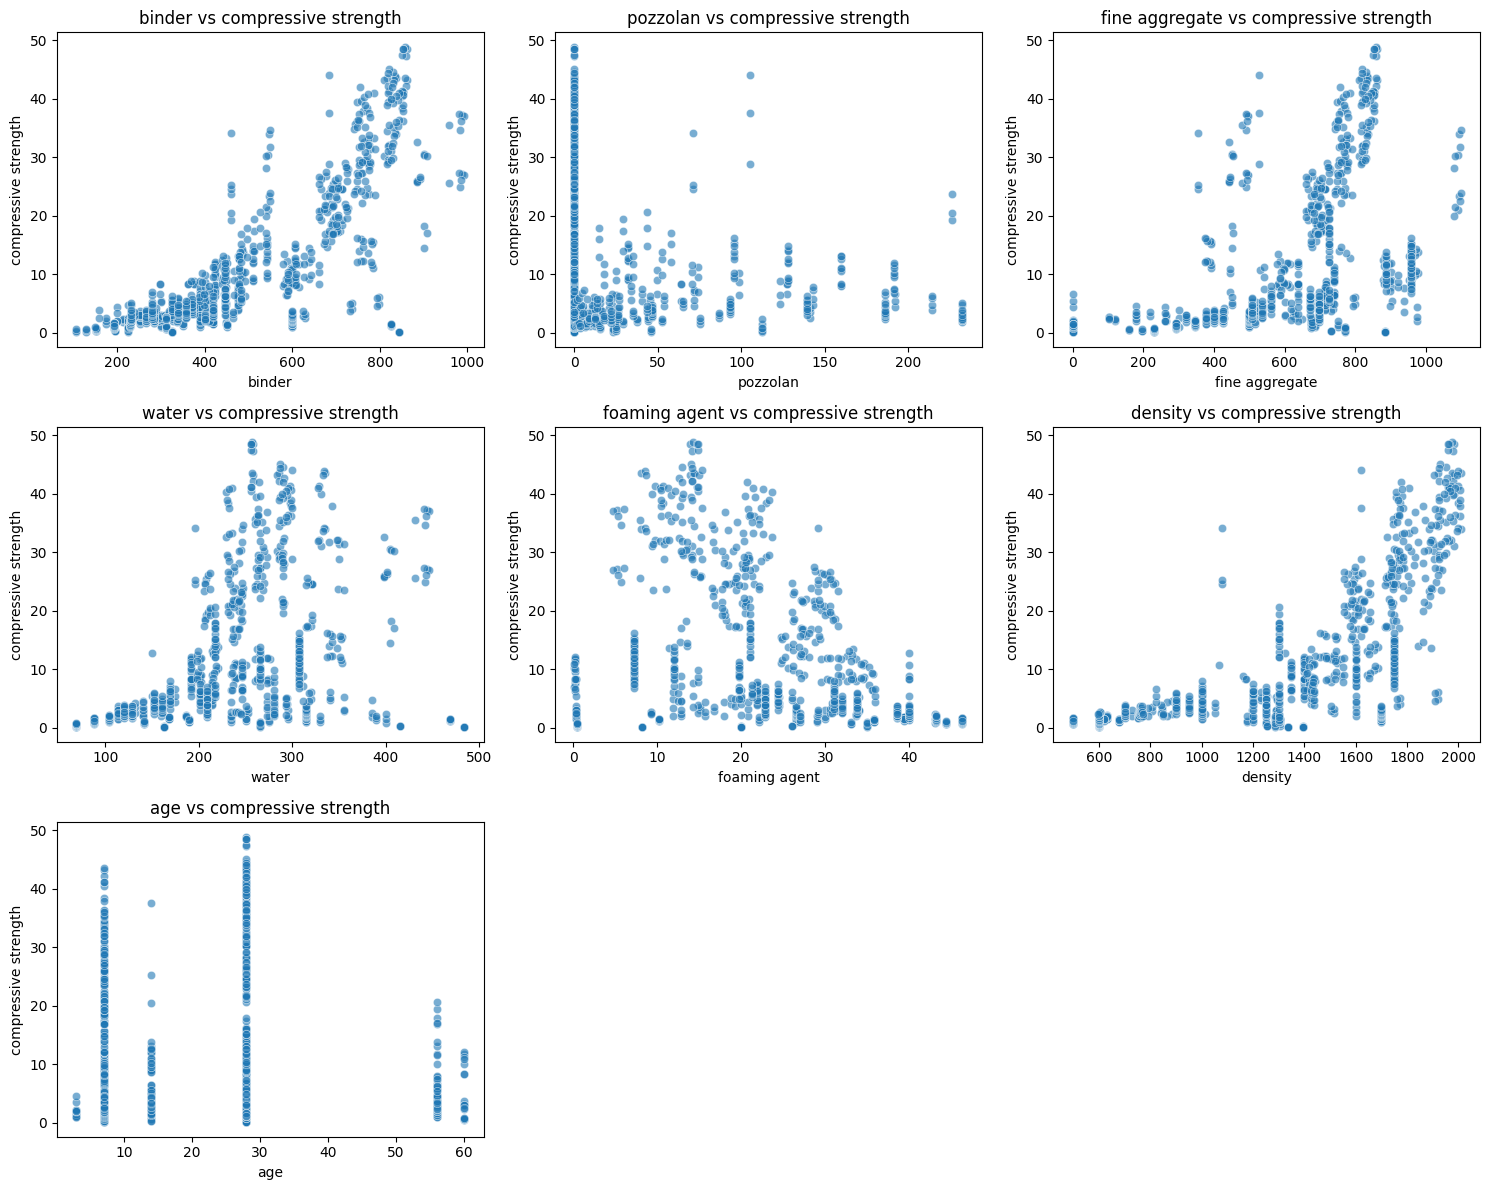

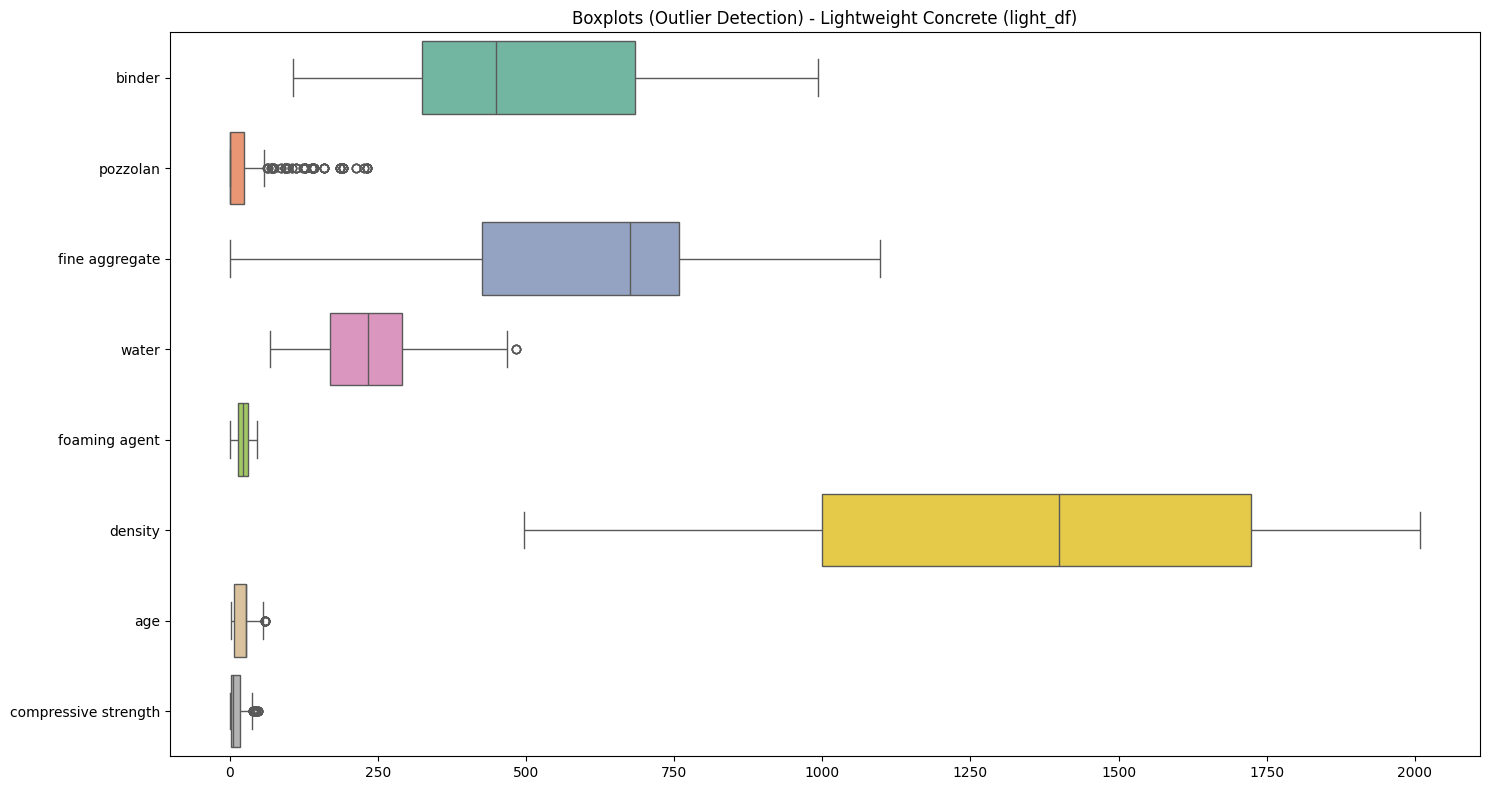

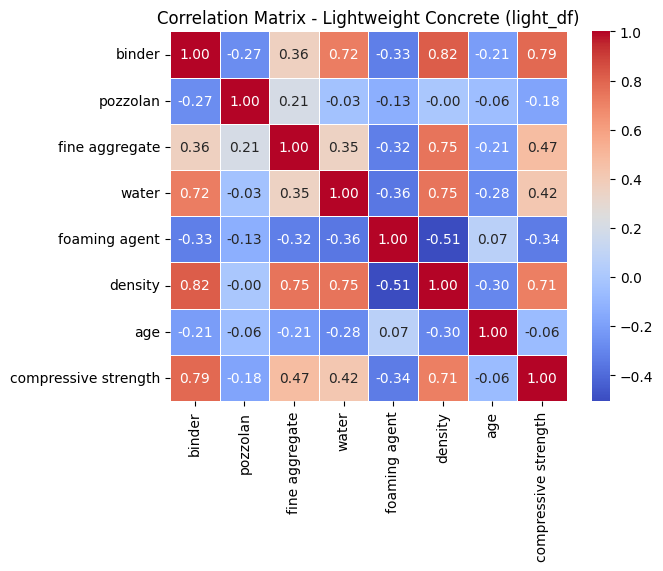

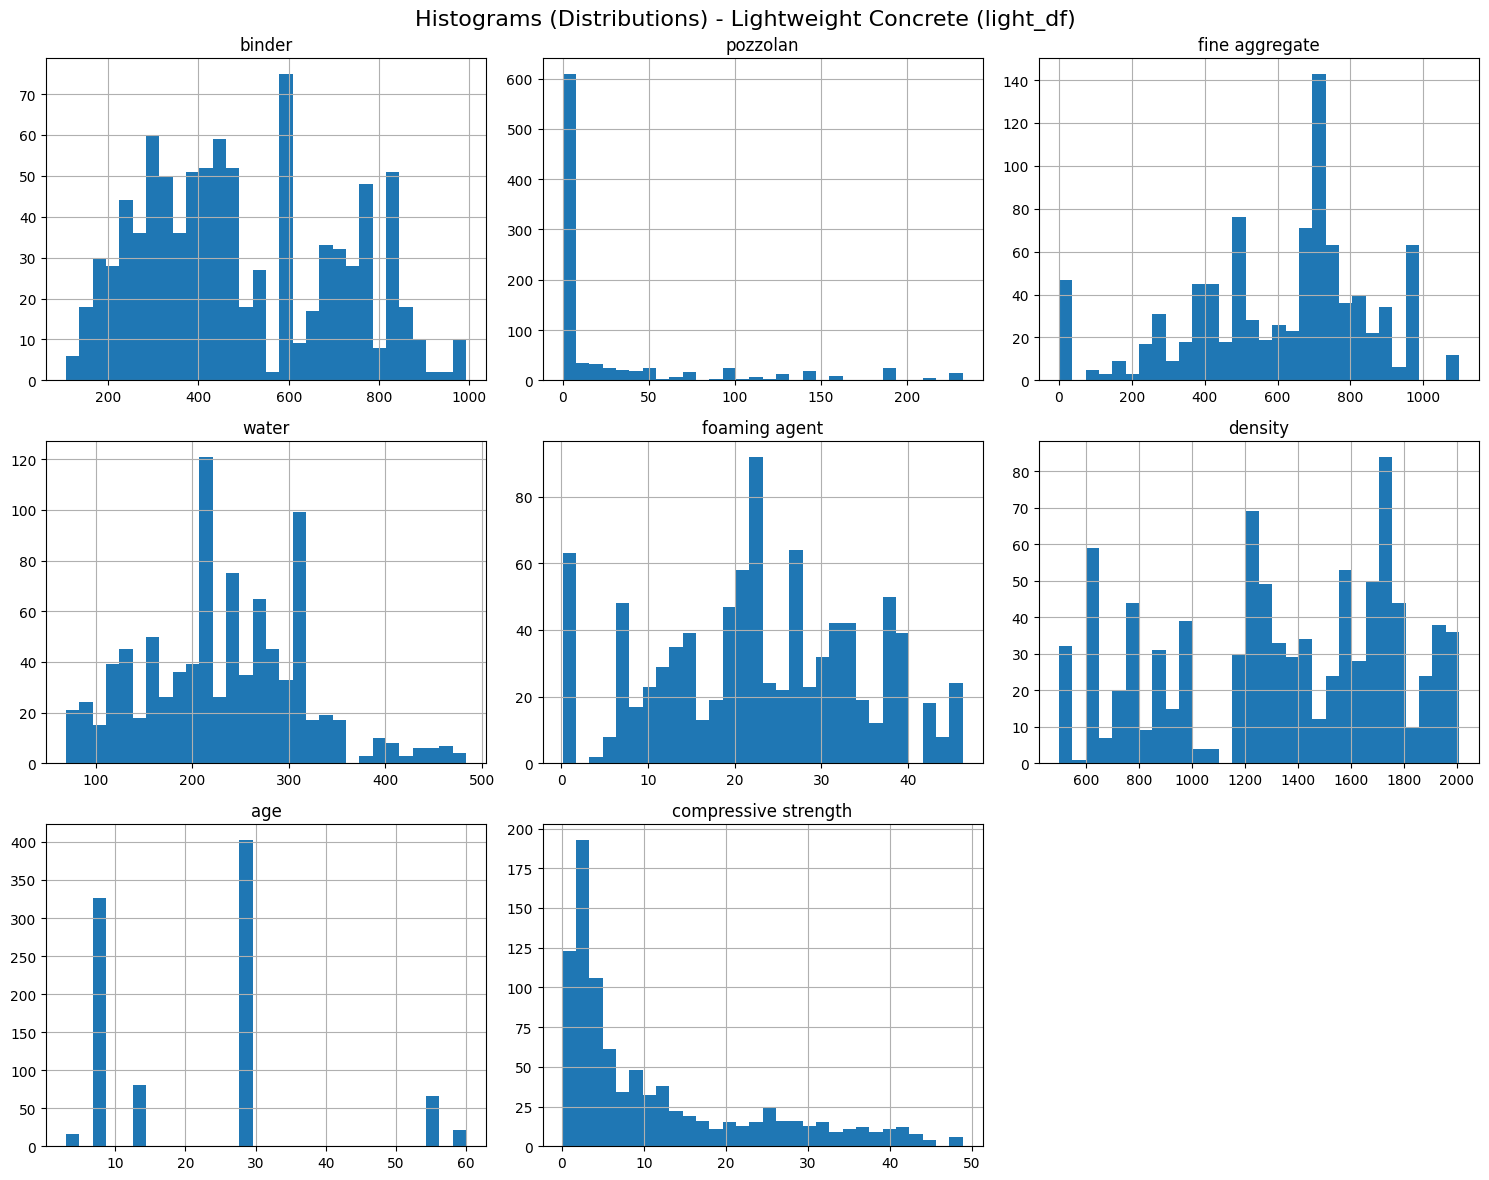

In [11]:
main_df = df.copy()
print(f"Lightweight original: {len(main_df)} rows")

main_df = main_df[main_df['age'] < 175]
main_df = main_df[main_df['pozzolan'] <= 250]
main_df = main_df[main_df['fine aggregate'] < 1100]
main_df = main_df[(main_df['density'] > 400) & (main_df['density'] <= 2200)]
main_df = main_df[main_df['binder'] > 0]
main_df = main_df[main_df['compressive strength'] > 0]
main_df = main_df[main_df['foaming agent'] < 50]

print(f"Lightweight after cleaning: {len(main_df)} rows\n")

analyze_dataset(main_df, "Lightweight Concrete (light_df)")

In [12]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 0 to 1005
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   binder                912 non-null    float64
 1   pozzolan              912 non-null    float64
 2   fine aggregate        912 non-null    float64
 3   water                 912 non-null    float64
 4   foaming agent         912 non-null    float64
 5   density               912 non-null    float64
 6   age                   912 non-null    int64  
 7   compressive strength  912 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 64.1 KB


In [13]:
main_df.describe().T

,count,mean,std,min,25%,50%,75%,max
binder,912.0,496.204539,211.795982,107.20,325.000,450.185,683.85000,992.80
pozzolan,912.0,26.982851,53.850722,0.00,0.000,0.000,25.00000,232.50
fine aggregate,912.0,602.281776,247.383851,0.00,426.600,675.000,758.20000,1098.00
water,912.0,233.005640,84.116711,68.90,169.000,234.000,290.52125,484.00
foaming agent,912.0,23.008070,11.908609,0.17,14.100,22.800,31.90000,46.30
density,912.0,1340.183399,433.512939,497.00,1000.000,1400.000,1724.14750,2009.48
age,912.0,21.589912,15.008985,3.00,7.000,28.000,28.00000,60.00
compressive strength,912.0,11.482921,12.080934,0.08,2.565,5.800,17.07000,48.88


In [14]:
main_df.nunique()

binder                  227
pozzolan                 86
fine aggregate          209
water                   206
foaming agent           181
density                 219
age                       6
compressive strength    697
dtype: int64

<Axes: >

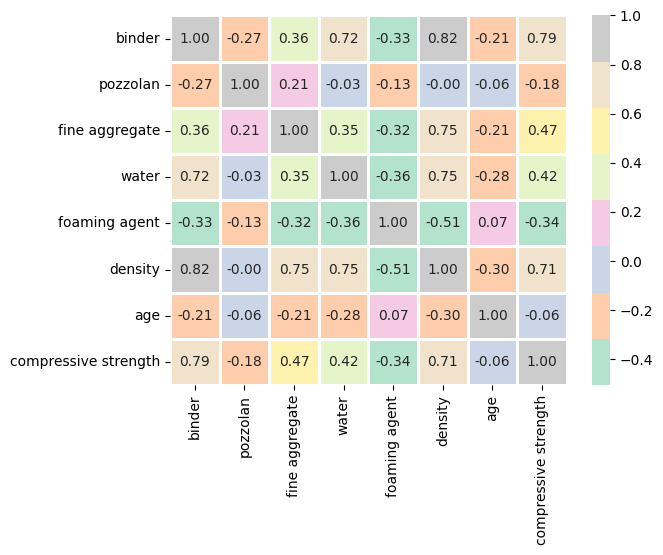

In [15]:
# Multivariate analysis

import seaborn as sns

sns.heatmap(main_df.corr(), annot=True, cmap='Pastel2', fmt='.2f', linewidths=2)

Dataset Preparation

In [16]:
X = main_df.drop('compressive strength', axis=1)
y = main_df['compressive strength']

X.shape, y.shape

((912, 7), (912,))

In [17]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% for validation+test combined
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: Split the 30% into 50/50 (15% validation, 15% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"\nSplit percentages:")
print(f"Train: {len(X_train) / len(X):.1%}")
print(f"Validation: {len(X_val) / len(X):.1%}")
print(f"Test: {len(X_test) / len(X):.1%}")

Train: (638, 7)
Validation: (137, 7)
Test: (137, 7)

Split percentages:
Train: 70.0%
Validation: 15.0%
Test: 15.0%


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")

# Fit on training data only
X_train = scaler.fit_transform(X_train)
# Transform validation and test without refitting
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR #support vector regression
from sklearn.neighbors import KNeighborsRegressor 
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

In [21]:
import os
import joblib
import json 
from sklearn.model_selection import GridSearchCV
model_dir = "saved_models"

In [22]:
def load_or_train_model(model_name, train_logic_func):
    """
    Checks if a model exists. If it does, loads it. 
    If not, runs the provided training logic and saves the model.
    """
    directory = f'{model_dir}/lightweight_dataset_regression_research_models'
    model_path = f'{directory}/{model_name}.pkl'
    model_config_path = f'{directory}/{model_name}.json'
    os.makedirs(directory, exist_ok=True)

    if os.path.exists(model_path):
        print(f"[{model_name}] Found saved model. Loading...")
        best_params = None
        if os.path.exists(model_config_path):
            with open(model_config_path, 'r') as f:
                best_params = json.load(f)
            print(f"[{model_name}] Loaded model parameters: {best_params}")
        return joblib.load(model_path), best_params
    else:
        print(f"[{model_name}] No saved model found. Training now...")
        
        # Execute the training function
        trained_model, trained_model_params = train_logic_func()
        
        # Save after training
        os.makedirs('saved_models', exist_ok=True)
        joblib.dump(trained_model, model_path)
        with open(model_config_path, 'w') as f:
            json.dump(trained_model_params, f, indent=4)
        print(f"[{model_name}] Training complete and model saved!\n")
        
        return trained_model, trained_model_params

In [23]:
from sklearn.model_selection import cross_val_score
import optuna

In [24]:
#Linear Regression

def train_optuna_linear_regression():
    def objective(trial):
        # The only remaining valid parameter to tune
        fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
        
        lr = LinearRegression(fit_intercept=fit_intercept)
        
        # 5-Fold Cross Validation
        scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        return scores.mean() 

    study = optuna.create_study(direction="maximize", study_name="linear_regression_opt")
    study.optimize(objective, n_trials=5) # Only 5 trials needed for 2 boolean combinations

    print(f"Best Linear Regression params: {study.best_params}")
    
    # Retrain on the full training set with the best parameters
    best_lr = LinearRegression(**study.best_params)
    best_lr.fit(X_train, y_train)
    
    return best_lr, study.best_params

In [25]:
#catboost regressor

from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
import optuna

def train_optuna_catboost():
    def objective(trial):
        params = {
            # Continuous ranges instead of discrete lists
            'iterations': trial.suggest_int('iterations', 100, 500, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'verbose': 0 # Keep logs quiet during trials
        }

        model = CatBoostRegressor(**params)
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        
        # MEMORY FIX: Explicit cleanup
        del model
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="catboost_opt")
    # MEMORY FIX: Reduced from 30 to 20 trials
    study.optimize(objective, n_trials=20)

    print(f"Best CatBoost params: {study.best_params}")
    
    # Retrain final model
    best_catboost = CatBoostRegressor(**study.best_params, verbose=0)
    best_catboost.fit(X_train, y_train)
    
    return best_catboost, study.best_params


In [26]:
#gradient boosting regressor

from sklearn.ensemble import GradientBoostingRegressor

def train_grid_gradient_boosting():
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    gb_model = GradientBoostingRegressor()
    grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_gb = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_gb, best_params

In [27]:
# LightGBM Regressor

from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
import optuna

def train_optuna_lgbm():
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'boosting_type': 'gbdt',
            'verbose': -1,
            'random_state': 42,
            # FIX: Restrict LightGBM to 1 thread per CV fold to prevent deadlock
            'n_jobs': 1 
        }

        model = LGBMRegressor(**params)
        
        # Keep n_jobs=-1 here so it runs the 5 folds in parallel
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        
        # MEMORY FIX: Explicit cleanup
        del model
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="lgbm_opt")
    # MEMORY FIX: Reduced from 30 to 20 trials
    study.optimize(objective, n_trials=20)

    print(f"Best LGBM params: {study.best_params}")
    
    # Retrain final model (You can let this use all cores since CV is done)
    best_lgbm = LGBMRegressor(**study.best_params, n_jobs=-1)
    best_lgbm.fit(X_train, y_train)
    
    return best_lgbm, study.best_params


In [28]:
#Decision Tree Regressor

def train_grid_decision_tree():
    dt_params = {
        'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'splitter': ['best', 'random'],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    dt = DecisionTreeRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=dt, param_grid=dt_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_dt = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_dt, best_params

In [29]:
#Random Forest

def train_grid_random_forest():
    rf_params = {
        'n_estimators': [100, 200, 300],
        'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_rf, best_params

In [30]:
#Support Vector Regression

def train_grid_svr():
    svr_params = {
        'kernel': ['linear', 'rbf', 'poly'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }

    svr = SVR()
    grid_search = GridSearchCV(estimator=svr, param_grid=svr_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_svr = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_svr, best_params

In [31]:
#K-Nearest Neighbors

def train_grid_knn():
    knn_params = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }

    knn = KNeighborsRegressor()
    grid_search = GridSearchCV(estimator=knn, param_grid=knn_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_knn = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_knn, best_params

In [32]:
#XGBoost Regressor

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import optuna
import gc # Import Python's garbage collector

def train_optuna_xgboost():
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7), 
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            
            # --- THE MEMORY SAVERS ---
            'tree_method': 'hist',
            'n_jobs': -1           # Safe to use all cores because we are only training 1 model at a time
        }

        model = XGBRegressor(**params)
        
        # OOM FIX: n_jobs=1 prevents holding 5 heavy models in memory simultaneously
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
        
        # Force Python to clear the RAM immediately after the fold finishes
        del model
        gc.collect() 
        
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="xgb_opt")
    # MEMORY FIX: Reduced from 20 to 15 trials
    study.optimize(objective, n_trials=15) 

    print(f"Best XGBoost params: {study.best_params}")
    
    # Retrain final model
    best_params = study.best_params
    best_params['tree_method'] = 'hist' # Ensure final model uses the lightweight method
    
    best_xgb = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    best_xgb.fit(X_train, y_train)
    
    return best_xgb, study.best_params


In [33]:
#ann 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import copy
import gc

# Set device to utilize GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Define the dynamic PyTorch Model
class DynamicANN(nn.Module):
    def __init__(self, trial, input_dim):
        super(DynamicANN, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Tune the number of hidden layers (1 to 3)
        num_layers = trial.suggest_int('num_layers', 1, 3)
        
        # Tune activation function globally for the network
        activation_name = trial.suggest_categorical('activation', ['relu', 'tanh'])
        activation_layer = nn.ReLU() if activation_name == 'relu' else nn.Tanh()
        
        in_features = input_dim
        
        for i in range(num_layers):
            # MEMORY FIX: Reduced max units from 256 to 128
            out_features = trial.suggest_int(f'units_{i}', 32, 128, step=32)
            self.layers.append(nn.Linear(in_features, out_features))
            self.layers.append(activation_layer)
            
            # Add Dropout to prevent overfitting
            dropout_rate = trial.suggest_float(f'dropout_{i}', 0.1, 0.5, step=0.1)
            self.layers.append(nn.Dropout(dropout_rate))
            
            in_features = out_features
            
        # Output layer for regression (1 node, linear activation)
        self.output = nn.Linear(in_features, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

# 2. Define the Optuna Objective Function
def objective(trial, train_loader, val_loader, input_dim):
    # Instantiate the model
    model = DynamicANN(trial, input_dim).to(device)
    
    # Tune the learning rate
    lr = trial.suggest_categorical('learning_rate', [1e-2, 1e-3, 1e-4])
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Early stopping variables
    patience = 10
    patience_counter = 0
    best_val_loss = float('inf')
    best_model_weights = None
    
    epochs = 100
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                # Multiply by batch size to calculate accurate average later
                val_loss += criterion(preds, batch_y).item() * batch_X.size(0)
                
        val_loss /= len(val_loader.dataset)
        
        # Report intermediate values for Optuna's Pruner
        trial.report(val_loss, epoch)
        
        # Stop unpromising trials early (Optuna feature, faster than Keras)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break # Trigger early stopping
            
    # MEMORY FIX: Aggressive cleanup after each trial
    del model
    del optimizer
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    
    # Save the best weights found during this specific trial into the trial object
    trial.set_user_attr("best_weights", best_model_weights)
    
    return best_val_loss

# 3. Main execution function
def tune_pytorch_ann():
    # Convert numpy arrays to PyTorch Tensors
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    X_val_np = np.array(X_val)
    y_val_np = np.array(y_val)

    X_train_t = torch.FloatTensor(X_train_np)
    y_train_t = torch.FloatTensor(y_train_np).view(-1, 1) # Ensure 2D shape
    X_val_t = torch.FloatTensor(X_val_np)
    y_val_t = torch.FloatTensor(y_val_np).view(-1, 1)
    
    # Create DataLoaders
    # MEMORY FIX: Reduced batch_size from 32 to 16
    batch_size = 16
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    input_dim = X_train.shape[1]
    
    # 4. Set up the Optuna Study
    study = optuna.create_study(
        study_name="ann_optimization",
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10) # Pruning mechanism
    )
    
    # Run the optimization
    # MEMORY FIX: Reduced n_trials from 30 to 20
    study.optimize(
        lambda trial: objective(trial, train_loader, val_loader, input_dim), 
        n_trials=20
    )
    
    # Retrieve the best hyperparameters
    best_trial = study.best_trial
    best_hps = best_trial.params
    
    # Reconstruct the best model using the saved weights
    best_keras_model = DynamicANN(best_trial, input_dim)
    best_keras_model.load_state_dict(best_trial.user_attrs["best_weights"])
    
    return best_keras_model, best_hps

# Execution example:
# best_model, best_params = tune_pytorch_ann(X_train, y_train, X_val, y_val)
    

Using device: cuda


In [34]:
import os
import json
import torch
import torch.nn as nn

# 1. Create a dedicated Loader Class (Does not affect your original DynamicANN)
class InferenceANN(nn.Module):
    """
    A standalone class used STRICTLY for reconstructing the PyTorch model 
    from saved JSON parameters without needing Optuna.
    """
    def __init__(self, input_dim, num_layers, units, dropouts, activation_name):
        super(InferenceANN, self).__init__()
        
        self.layers = nn.ModuleList()
        activation_layer = nn.ReLU() if activation_name == 'relu' else nn.Tanh()
        
        in_features = input_dim
        
        for i in range(num_layers):
            out_features = units[i]
            self.layers.append(nn.Linear(in_features, out_features))
            self.layers.append(activation_layer)
            
            # Add Dropout
            self.layers.append(nn.Dropout(p=dropouts[i]))
            
            in_features = out_features
            
        # Output layer for regression
        self.output = nn.Linear(in_features, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

# 2. Update the load function to use the new InferenceANN class
def load_or_train_pytorch_model(model_name, train_logic_func, input_dim):
    """
    Dedicated PyTorch save/load flow utilizing state_dicts and handling device mapping.
    """
    model_dir = 'saved_models'
    directory = f'{model_dir}/geopolymer_dataset_regression_research_models'
    
    model_path = f'{directory}/{model_name}.pth' 
    model_config_path = f'{directory}/{model_name}.json'
    
    os.makedirs(directory, exist_ok=True)

    if os.path.exists(model_path) and os.path.exists(model_config_path):
        print(f"[{model_name}] Found saved PyTorch weights. Loading...")
        
        with open(model_config_path, 'r') as f:
            best_params = json.load(f)
            
        print(f"[{model_name}] Loaded model parameters: {best_params}")
        
        # Parse the saved parameters
        num_layers = best_params['num_layers']
        activation = best_params['activation']
        units = [best_params[f'units_{i}'] for i in range(num_layers)]
        dropouts = [best_params[f'dropout_{i}'] for i in range(num_layers)]
        
        # USE THE NEW CLASS HERE:
        loaded_model = InferenceANN(input_dim, num_layers, units, dropouts, activation)
        
        loaded_model.load_state_dict(torch.load(model_path, map_location=device))
        loaded_model.to(device)
        loaded_model.eval() 
        
        return loaded_model, best_params

    else:
        print(f"[{model_name}] No saved model found. Training now...")
        
        # Executes your original Optuna code with the original DynamicANN
        trained_model, trained_model_params = train_logic_func()
        
        torch.save(trained_model.state_dict(), model_path)
        
        with open(model_config_path, 'w') as f:
            json.dump(trained_model_params, f, indent=4)
            
        print(f"[{model_name}] Training complete and PyTorch weights saved!\n")
        
        return trained_model, trained_model_params

In [ ]:
#linear regression
best_lr, best_lr_params = load_or_train_model("linear_regression", train_optuna_linear_regression)

In [ ]:
#catboost regressor
best_catboost, best_catboost_params = load_or_train_model("catboost_regressor", train_optuna_catboost)

[I 2026-06-18 09:49:40,742] A new study created in memory with name: catboost_opt


[catboost_regressor] No saved model found. Training now...


[I 2026-06-18 09:49:49,013] Trial 0 finished with value: -8.21573384683468 and parameters: {'iterations': 300, 'learning_rate': 0.05456767367188926, 'depth': 8, 'l2_leaf_reg': 4.81995702231074}. Best is trial 0 with value: -8.21573384683468.
[I 2026-06-18 09:49:59,925] Trial 1 finished with value: -13.8667770812939 and parameters: {'iterations': 100, 'learning_rate': 0.05437708009432734, 'depth': 9, 'l2_leaf_reg': 8.218881633030776}. Best is trial 0 with value: -8.21573384683468.


In [ ]:
#lgbm regressor
best_lgbm, best_lgbm_params = load_or_train_model("lgbm_regressor", train_optuna_lgbm)

In [ ]:
#gradient boosting regressor
best_gb, best_gb_params = load_or_train_model("gradient_boosting_regressor", train_grid_gradient_boosting)

In [ ]:
#decision tree regressor
best_dt, best_dt_params = load_or_train_model("decision_tree_regressor", train_grid_decision_tree)

In [ ]:
#svr
best_svr, best_svr_params = load_or_train_model("svr", train_grid_svr)

In [ ]:
#knn
best_knn, best_knn_params = load_or_train_model("knn", train_grid_knn)

In [ ]:
#xgboost
best_xgb, best_xgb_params = load_or_train_model("xgboost_regressor", train_optuna_xgboost)

In [ ]:
#random forest
best_rf, best_rf_params = load_or_train_model("random_forest_regressor", train_grid_random_forest)

In [ ]:
#train or load ann
best_ann_model, best_ann_params = load_or_train_pytorch_model("ann_model", tune_pytorch_ann, input_dim=X_train.shape[1])

In [ ]:
# evaluation of the loaded models

lr_eval = evaluate_model(y_test, best_lr.predict(X_test))
catboost_eval = evaluate_model(y_test, best_catboost.predict(X_test))
lgbm_eval = evaluate_model(y_test, best_lgbm.predict(X_test))
gb_eval = evaluate_model(y_test, best_gb.predict(X_test))
dt_eval = evaluate_model(y_test, best_dt.predict(X_test))
rf_eval = evaluate_model(y_test, best_rf.predict(X_test))
svr_eval = evaluate_model(y_test, best_svr.predict(X_test))
knn_eval = evaluate_model(y_test, best_knn.predict(X_test))
xgb_eval = evaluate_model(y_test, best_xgb.predict(X_test))

X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
ann_model_eval = evaluate_model(y_test, best_ann_model(X_test_tensor).cpu().detach().numpy().squeeze())

In [ ]:
# Collecting all evaluations in a dictionary for easy comparison

all_evaluations = {
    "Linear Regression": lr_eval,
    "CatBoost Regressor": catboost_eval,
    "LightGBM Regressor": lgbm_eval,
    "Gradient Boosting Regressor": gb_eval,
    "Decision Tree Regressor": dt_eval,
    "Random Forest Regressor": rf_eval,
    "Support Vector Regressor": svr_eval,
    "K-Nearest Neighbors": knn_eval,
    "XGBoost Regressor": xgb_eval,
    "ANN (PyTorch)": ann_model_eval
}

Visualization

In [ ]:
# Combined Comparison: lower, the better

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# RMSE Comparison
rmse_values = [evals['RMSE'] for evals in all_evaluations.values()]
axes[0, 0].bar(all_evaluations.keys(), rmse_values, color='skyblue')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)')
axes[0, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# MSE Comparison
mse_values = [evals['MSE'] for evals in all_evaluations.values()]
axes[0, 1].bar(all_evaluations.keys(), mse_values, color='lightcoral')
axes[0, 1].set_title('MSE Comparison (Lower is Better)')
axes[0, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# MAE Comparison
mae_values = [evals['MAE'] for evals in all_evaluations.values()]
axes[1, 0].bar(all_evaluations.keys(), mae_values, color='salmon')
axes[1, 0].set_title('MAE Comparison (Lower is Better)')
axes[1, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# R2 Score Comparison
r2_values = [evals['R2 Score'] for evals in all_evaluations.values()]
axes[1, 1].bar(all_evaluations.keys(), r2_values, color='lightgreen')
axes[1, 1].set_title('R2 Score Comparison (Higher is Better)')
axes[1, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')



plt.tight_layout()
plt.show()

In [ ]:
#feature importance of the random forest regression model.

print(main_df.columns[:-1])
print(best_rf.feature_importances_)

rf_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importances['feature'], rf_importances['importance'], color='lightblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [ ]:
#Feature importance of the XGBoost regression model.

xgb_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(xgb_importances['feature'], xgb_importances['importance'], color='salmon')
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [ ]:
# feature importance of the lightgbm regression model.

lgbm_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_lgbm.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(lgbm_importances['feature'], lgbm_importances['importance'], color='lightgreen')
plt.xlabel('Feature Importance')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [ ]:
#feature importance of the catboost regression model.

catboost_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_catboost.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(catboost_importances['feature'], catboost_importances['importance'], color='lightcoral')
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [ ]:
# feature importance of the gradient boosting regression model.

gb_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_gb.feature_importances_
}).sort_values(by='importance', ascending=False)    

plt.figure(figsize=(10, 6))
plt.barh(gb_importances['feature'], gb_importances['importance'], color='plum')
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [ ]:
import shap

In [ ]:
# shap analysis for random forest regression model

explainer_rf = shap.PermutationExplainer(best_rf.predict, X_test)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("Random Forest SHAP Feature Importance")
plt.tight_layout()
plt.show()

# coarse aggregate and age are the most important features for the random forest regression model according to the shap analysis.
plt.figure(figsize=(10, 6))
shap.dependence_plot("coarse aggregate", shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Coarse Aggregate (Random Forest)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (Random Forest)")
plt.tight_layout()
plt.show()

In [ ]:
# shap analysis for the Xgboost regression model

explainer_xgb = shap.PermutationExplainer(best_xgb.predict, X_test)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("XGBoost SHAP Feature Importance")
plt.tight_layout()
plt.show()

# curing temperature and alkaline solution are the most important features for the XGBoost regression model according to the shap analysis.
plt.figure(figsize=(10, 6))
shap.dependence_plot("curing temperature", shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Curing Temperature (XGBoost)")
plt.tight_layout()
plt.show()  

plt.figure(figsize=(10, 6))
shap.dependence_plot("alkaline solution", shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Alkaline Solution (XGBoost)")
plt.tight_layout()  
plt.show()

In [ ]:
#feature importance of the catboost regression model. age and fine aggregate are the most important features for the catboost regression model according to the shap analysis.

explainer_catboost = shap.PermutationExplainer(best_catboost.predict, X_test)
shap_values_catboost = explainer_catboost.shap_values(X_test)
shap.summary_plot(shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("CatBoost SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (CatBoost)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (CatBoost)")
plt.tight_layout()
plt.show()


In [ ]:
#feature importance of the lightgbm regression model.

#coarse aggregate and fine aggregate are the most important features for the lightgbm regression model according to the shap analysis.

explainer_lgbm = shap.PermutationExplainer(best_lgbm.predict, X_test)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)
shap.summary_plot(shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("LightGBM SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("coarse aggregate", shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Coarse Aggregate (LightGBM)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (LightGBM)")
plt.tight_layout()
plt.show()


In [ ]:
# shap values for the gradient boosting regression model

# fine aggregate and age are the most important features for the gradient boosting regression model according to the shap analysis.

explainer_gb = shap.PermutationExplainer(best_gb.predict, X_test)
shap_values_gb = explainer_gb.shap_values(X_test)
shap.summary_plot(shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("Gradient Boosting SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (Gradient Boosting)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (Gradient Boosting)")
plt.tight_layout()
plt.show()


In [ ]:
# residual plots for all the best tree models

tree_models_pred = {
    "Random Forest": best_rf.predict(X_test),
    "XGBoost": best_xgb.predict(X_test),
    "LightGBM": best_lgbm.predict(X_test),
    "CatBoost": best_catboost.predict(X_test),
    "Gradient Boosting": best_gb.predict(X_test)
}

plt.figure(figsize=(12, 8))
for i, (model_name, predictions) in enumerate(tree_models_pred.items()):
    residuals = y_test - predictions
    plt.subplot(2, 3, i+1)
    plt.scatter(predictions, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"{model_name} Residuals")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

In [ ]:
# parity plots for all the best tree models

plt.figure(figsize=(12, 8))
for i, (model_name, predictions) in enumerate(tree_models_pred.items()):
    plt.subplot(2, 3, i+1)
    plt.scatter(y_test, predictions, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Line for perfect predictions
    plt.title(f"{model_name} Parity Plot")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()
